# Augmentation and Snapshot Exploration

This notebook merges the previous augmentation and synthetic snapshot explorations.
Reusable logic now lives in `src/uno_vision/data/augmentations.py` and `src/uno_vision/data/game_snapshots.py`.
The cells below stay close to the original workflow while removing duplicated utility code.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from uno_vision.data.augmentations import (
    crop_image_augmentations,
    generate_augmentations,
    load_aligned_mask,
    load_binary_mask,
    mask_augmentations,
)
from uno_vision.data.game_snapshots import (
    add_right_angle_rotations,
    generate_game_snapshots,
    load_reference_card_pools,
    make_scene,
)
from uno_vision.paths import AUGMENTATIONS_DIR, GAME_SNAPSHOTS_DIR, REFERENCE_CARDS_DIR

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference cards: {REFERENCE_CARDS_DIR}")
print(f"Augmentations: {AUGMENTATIONS_DIR}")
print(f"Game snapshots: {GAME_SNAPSHOTS_DIR}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Reference cards: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards
Augmentations: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\augmentations
Game snapshots: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\game_snapshots


In [3]:
source_tag = "L1000765"
crop_idx = 0

crop_path = REFERENCE_CARDS_DIR / source_tag / "crops" / f"crop_{crop_idx}.jpg"
mask_dir = REFERENCE_CARDS_DIR / source_tag / "masks"
img_bgr = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read crop: {crop_path}")

mask_fg = load_aligned_mask(mask_dir, crop_idx, img_bgr.shape[0], img_bgr.shape[1])
base_mask = load_binary_mask(mask_dir, crop_idx, img_bgr.shape[0], img_bgr.shape[1])
rng = np.random.default_rng(42)

print(f"Crop: {crop_path}")
print(f"Image shape: {img_bgr.shape}")

Crop: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\reference_cards\L1000765\crops\crop_0.jpg
Image shape: (561, 372, 3)


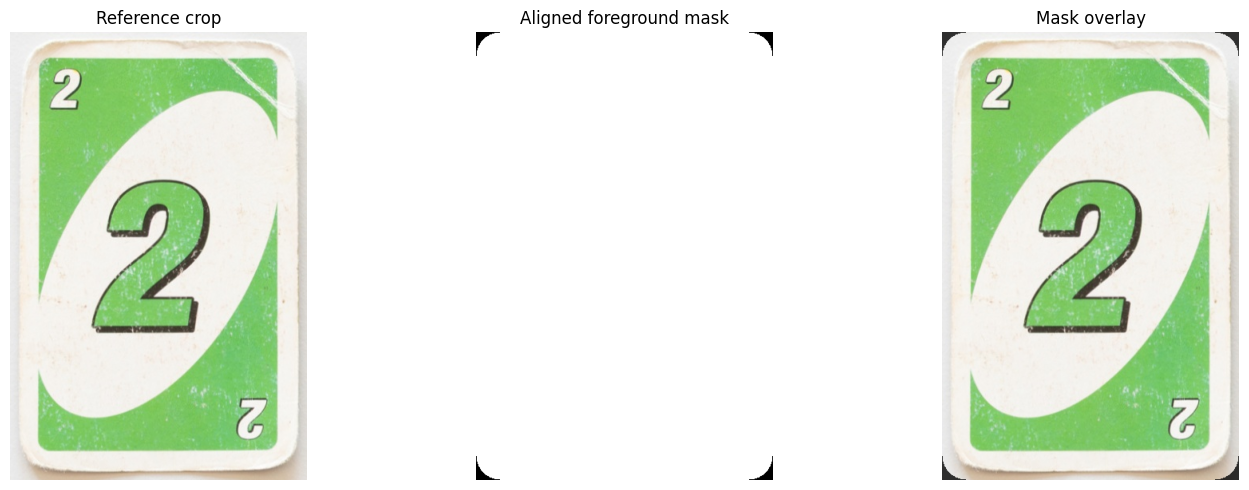

In [4]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
overlay = img_rgb.copy()
overlay[~mask_fg] = (overlay[~mask_fg] * 0.2).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Reference crop")
axes[0].axis("off")

axes[1].imshow(mask_fg, cmap="gray")
axes[1].set_title("Aligned foreground mask")
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Mask overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

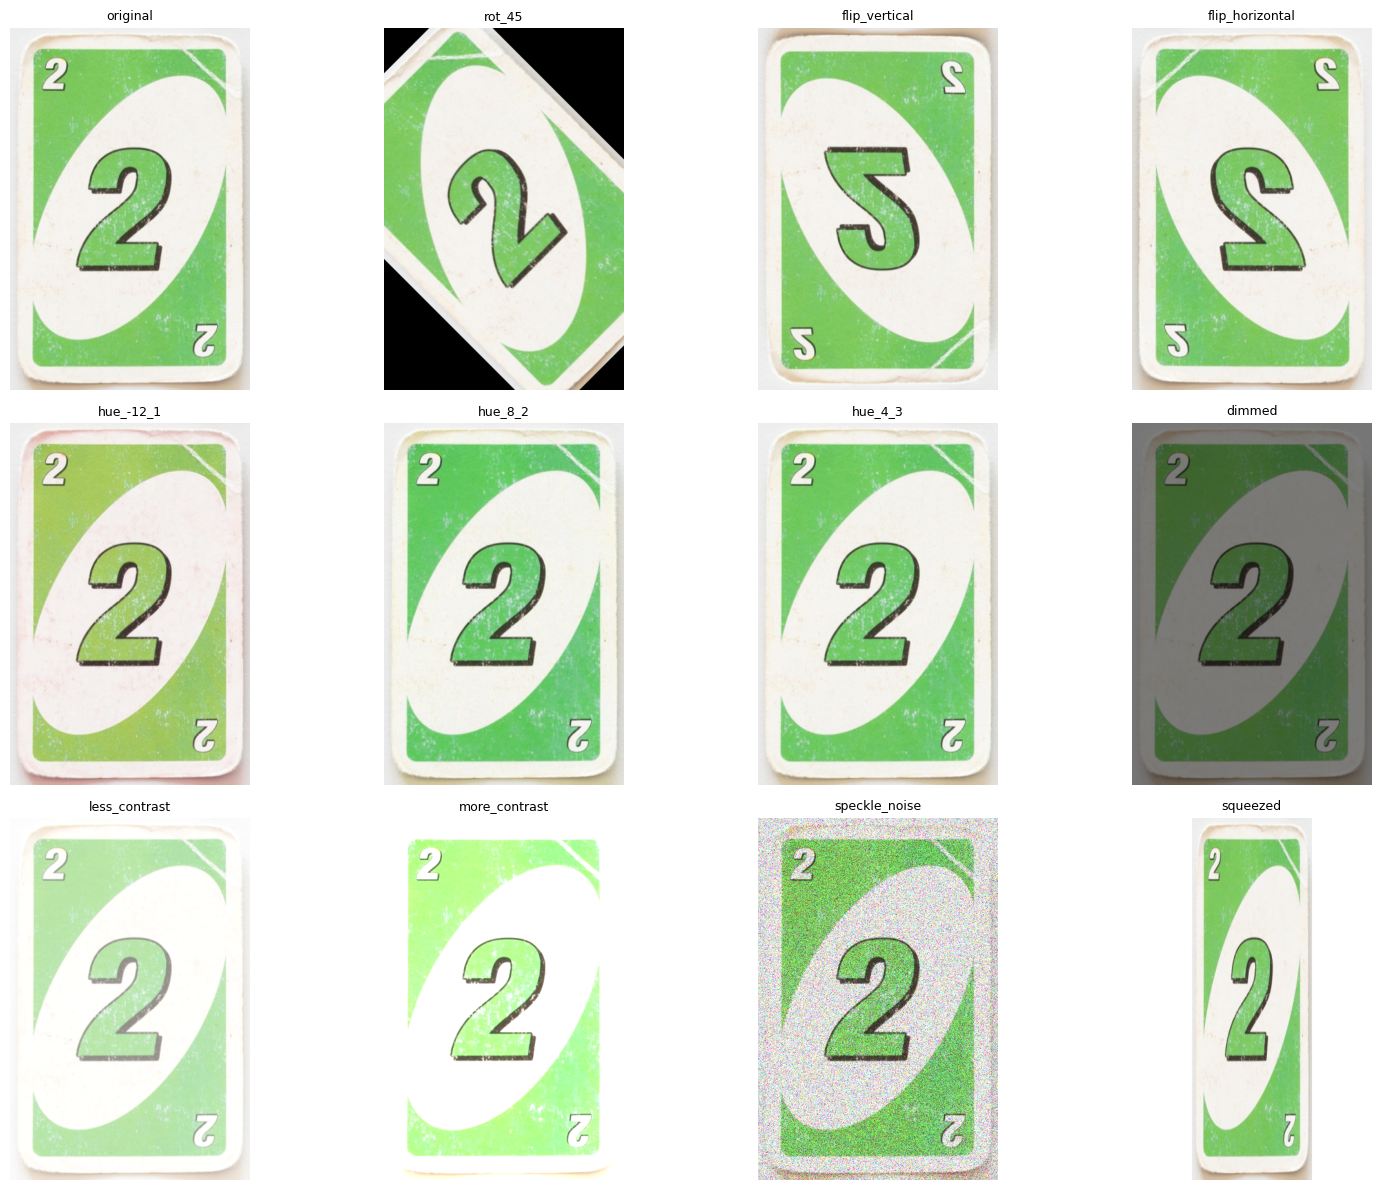

In [5]:
image_augs = [("original", img_bgr)] + crop_image_augmentations(img_bgr, mask_fg, rng)
preview = image_augs[:12]

rows = int(np.ceil(len(preview) / 4))
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, (name, aug_img) in zip(axes, preview):
    ax.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for ax in axes[len(preview):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

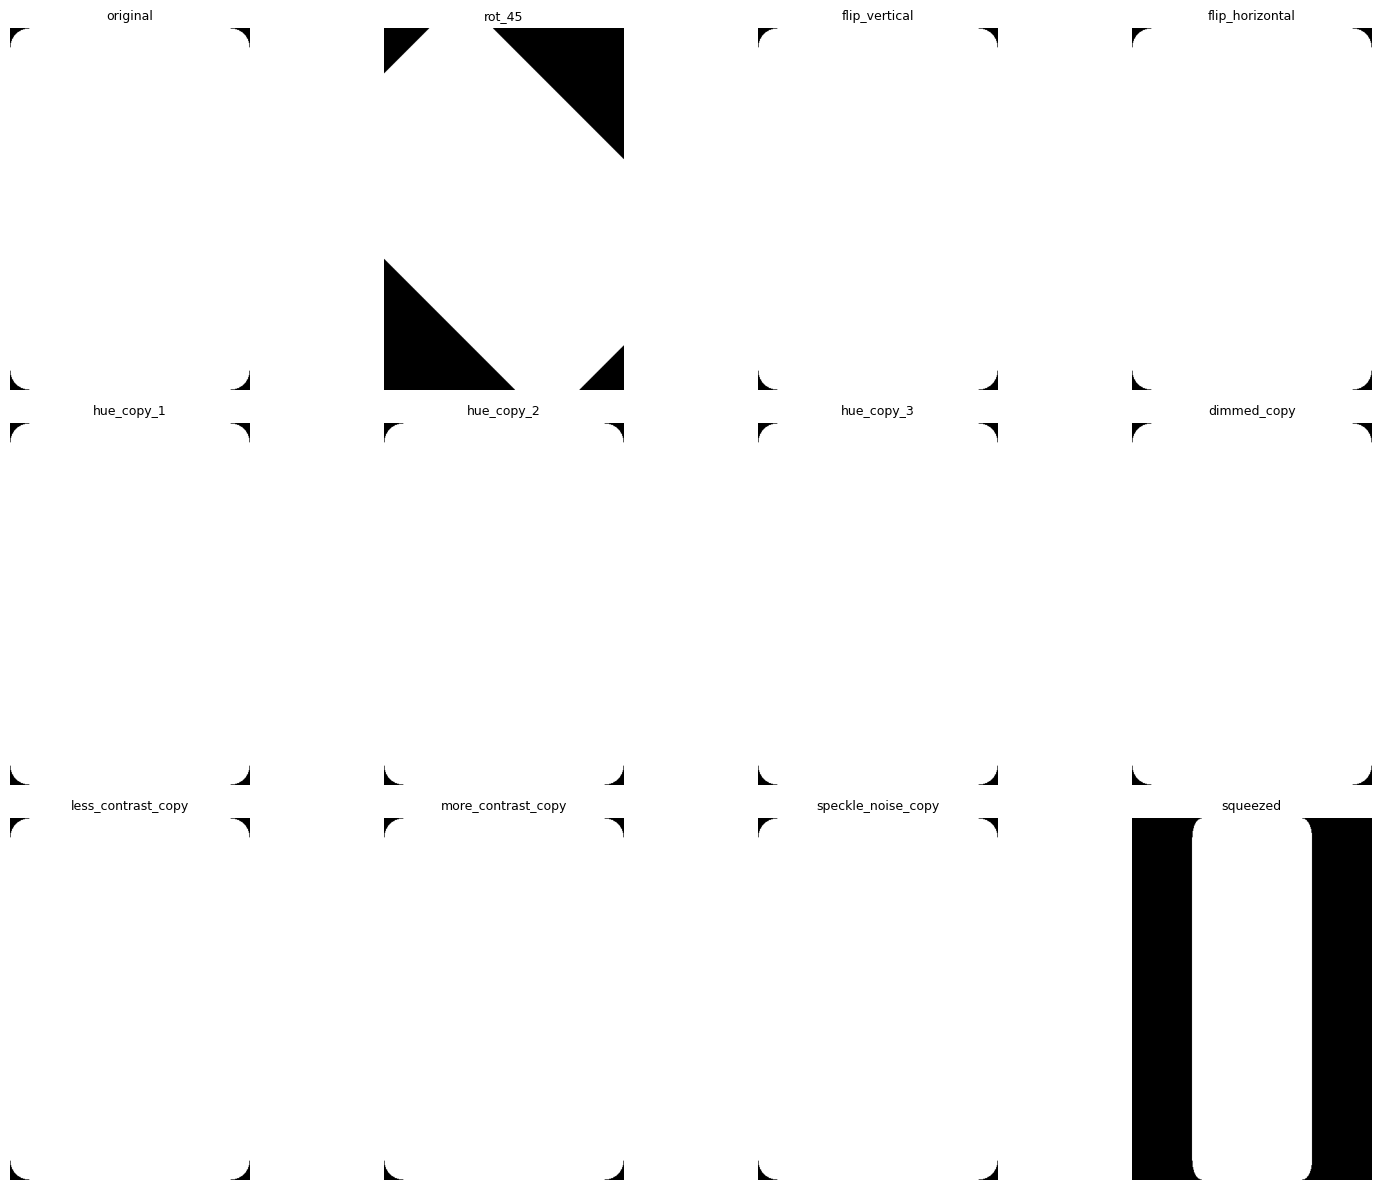

In [6]:
mask_augs = [("original", base_mask)] + mask_augmentations(base_mask, np.random.default_rng(42))
preview = mask_augs[:12]

rows = int(np.ceil(len(preview) / 4))
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, (name, aug_mask) in zip(axes, preview):
    ax.imshow(aug_mask, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")

for ax in axes[len(preview):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Run this cell only when you want to regenerate the full augmentation dataset.
image_count, mask_count = generate_augmentations(seed=42)
print(f"Generated {image_count} augmented images and {mask_count} augmented masks.")

Generated 1080 augmented images and 1080 augmented masks.


## Synthetic Game Snapshot Generation

These cells replace the duplicated implementation from the old snapshot notebook.
They use reusable helpers from `uno_vision.data.game_snapshots` and keep the same flow:
1. Load reference card pools
2. Preview one synthetic scene and mask
3. Optionally add +/-90° variants
4. Optionally generate and preview a dataset

In [8]:
scene_seed = 42
card_images, card_masks = load_reference_card_pools()
all_labels = sorted(card_images.keys())
total_crops = sum(len(v) for v in card_images.values())

print(f"Loaded {total_crops} reference crops across {len(all_labels)} card types.")
print(f"Card labels: {all_labels}")

rng_scene = np.random.default_rng(scene_seed)

Loaded 54 reference crops across 52 card types.
Card labels: ['b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'b_6', 'b_7', 'b_8', 'b_9', 'b_draw_2', 'b_reverse', 'b_skip', 'draw_4', 'g_0', 'g_1', 'g_2', 'g_3', 'g_4', 'g_5', 'g_6', 'g_7', 'g_8', 'g_9', 'g_draw_2', 'g_reverse', 'g_skip', 'r_0', 'r_1', 'r_2', 'r_3', 'r_4', 'r_5', 'r_6', 'r_7', 'r_8', 'r_9', 'r_draw_2', 'r_reverse', 'r_skip', 'wild', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'y_9', 'y_draw_2', 'y_reverse', 'y_skip']


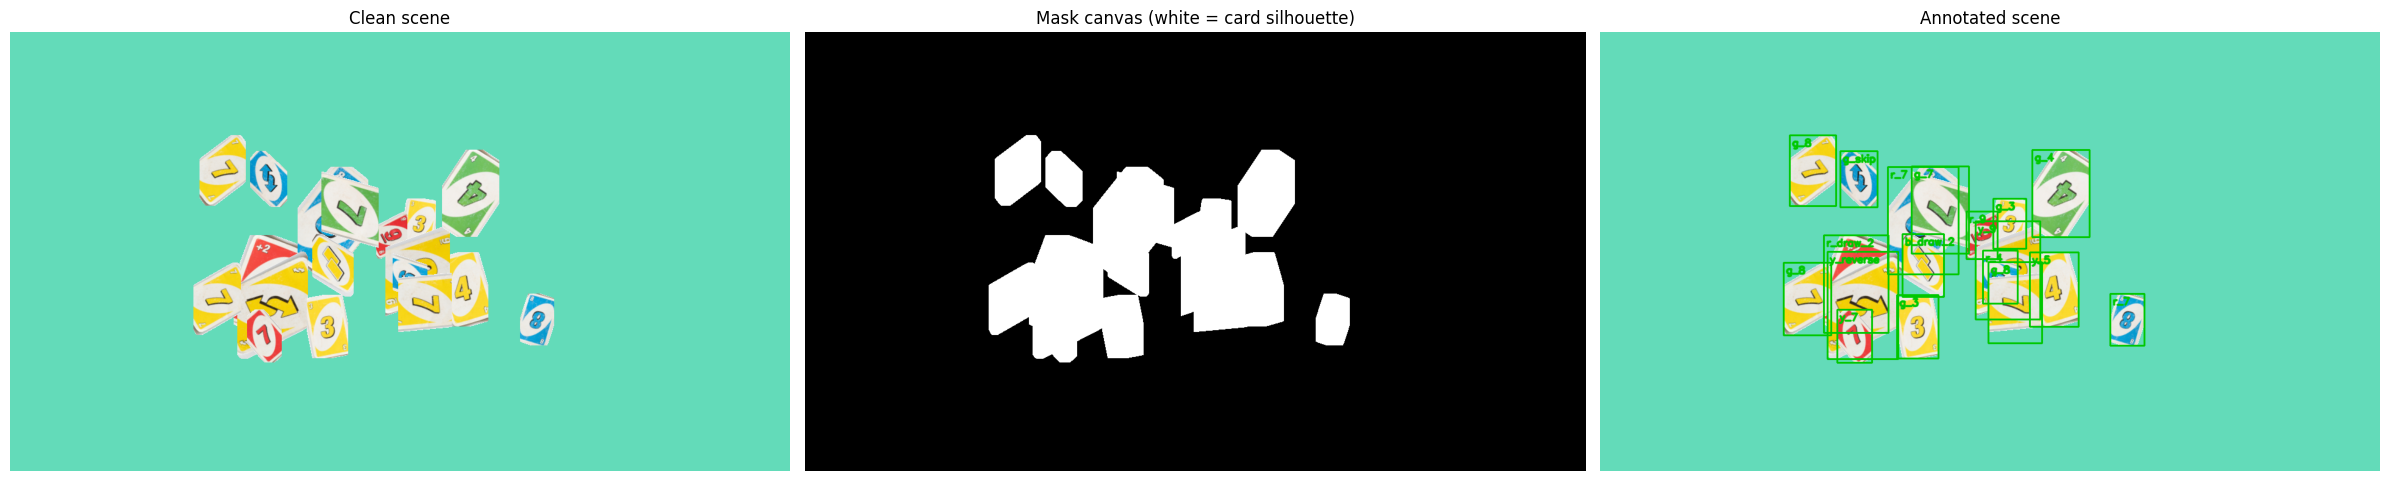

Cards placed: 18
  g_3       bbox=(645,273)-(699,355)
  r_7       bbox=(837,429)-(893,514)
  r_draw_2  bbox=(367,333)-(473,493)
  r_9       bbox=(601,294)-(652,372)
  r_7       bbox=(472,221)-(588,397)
  y_5       bbox=(705,361)-(785,483)
  y_reverse  bbox=(373,360)-(489,536)
  g_skip    bbox=(394,195)-(455,287)
  g_8       bbox=(301,378)-(379,497)
  y_9       bbox=(616,310)-(722,471)
  ... and 8 more


In [9]:
scene, mask_canvas, placements = make_scene(
    card_images,
    card_masks,
    rng_scene,
    scene_w=1280,
    scene_h=720,
)

vis = scene.copy()
for placement in placements:
    cv2.rectangle(
        vis,
        (placement["x1"], placement["y1"]),
        (placement["x2"], placement["y2"]),
        (0, 200, 0),
        2,
    )
    cv2.putText(
        vis,
        placement["label"],
        (placement["x1"] + 4, placement["y1"] + 18),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.55,
        (0, 200, 0),
        2,
        cv2.LINE_AA,
    )

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
axes[0].imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
axes[0].set_title("Clean scene")
axes[0].axis("off")

axes[1].imshow(mask_canvas, cmap="gray")
axes[1].set_title("Mask canvas (white = card silhouette)")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title("Annotated scene")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Cards placed: {len(placements)}")
for placement in placements[:10]:
    print(
        f"  {placement['label']:8s}  "
        f"bbox=({placement['x1']},{placement['y1']})-({placement['x2']},{placement['y2']})"
    )
if len(placements) > 10:
    print(f"  ... and {len(placements) - 10} more")

In [10]:
# Optional: expand each card with +/-90 degree variants before scene generation.
added_rotations = add_right_angle_rotations(card_images, card_masks)
print(f"Added {added_rotations} rotated variants (+90 and -90 degrees).")
print(
    f"Total crops now: {sum(len(v) for v in card_images.values())} "
    f"across {len(card_images)} card types."
)

Added 108 rotated variants (+90 and -90 degrees).
Total crops now: 162 across 52 card types.


In [11]:
# Run this cell only when you want to regenerate the full synthetic snapshot dataset.
N_SCENES = 500
SCENE_W = 1280
SCENE_H = 720

result = generate_game_snapshots(
    card_images,
    card_masks,
    save_dir=GAME_SNAPSHOTS_DIR,
    n_scenes=N_SCENES,
    scene_w=SCENE_W,
    scene_h=SCENE_H,
    seed=100,
)

print(f"Saved {result.scenes_generated} scenes  -> {result.images_dir}")
print(f"Saved {result.scenes_generated} masks   -> {result.masks_dir}")
print(f"Saved labels             -> {result.labels_path}")

Saved 500 scenes  -> C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\game_snapshots\images
Saved 500 masks   -> C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\game_snapshots\masks
Saved labels             -> C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\game_snapshots\labels.json


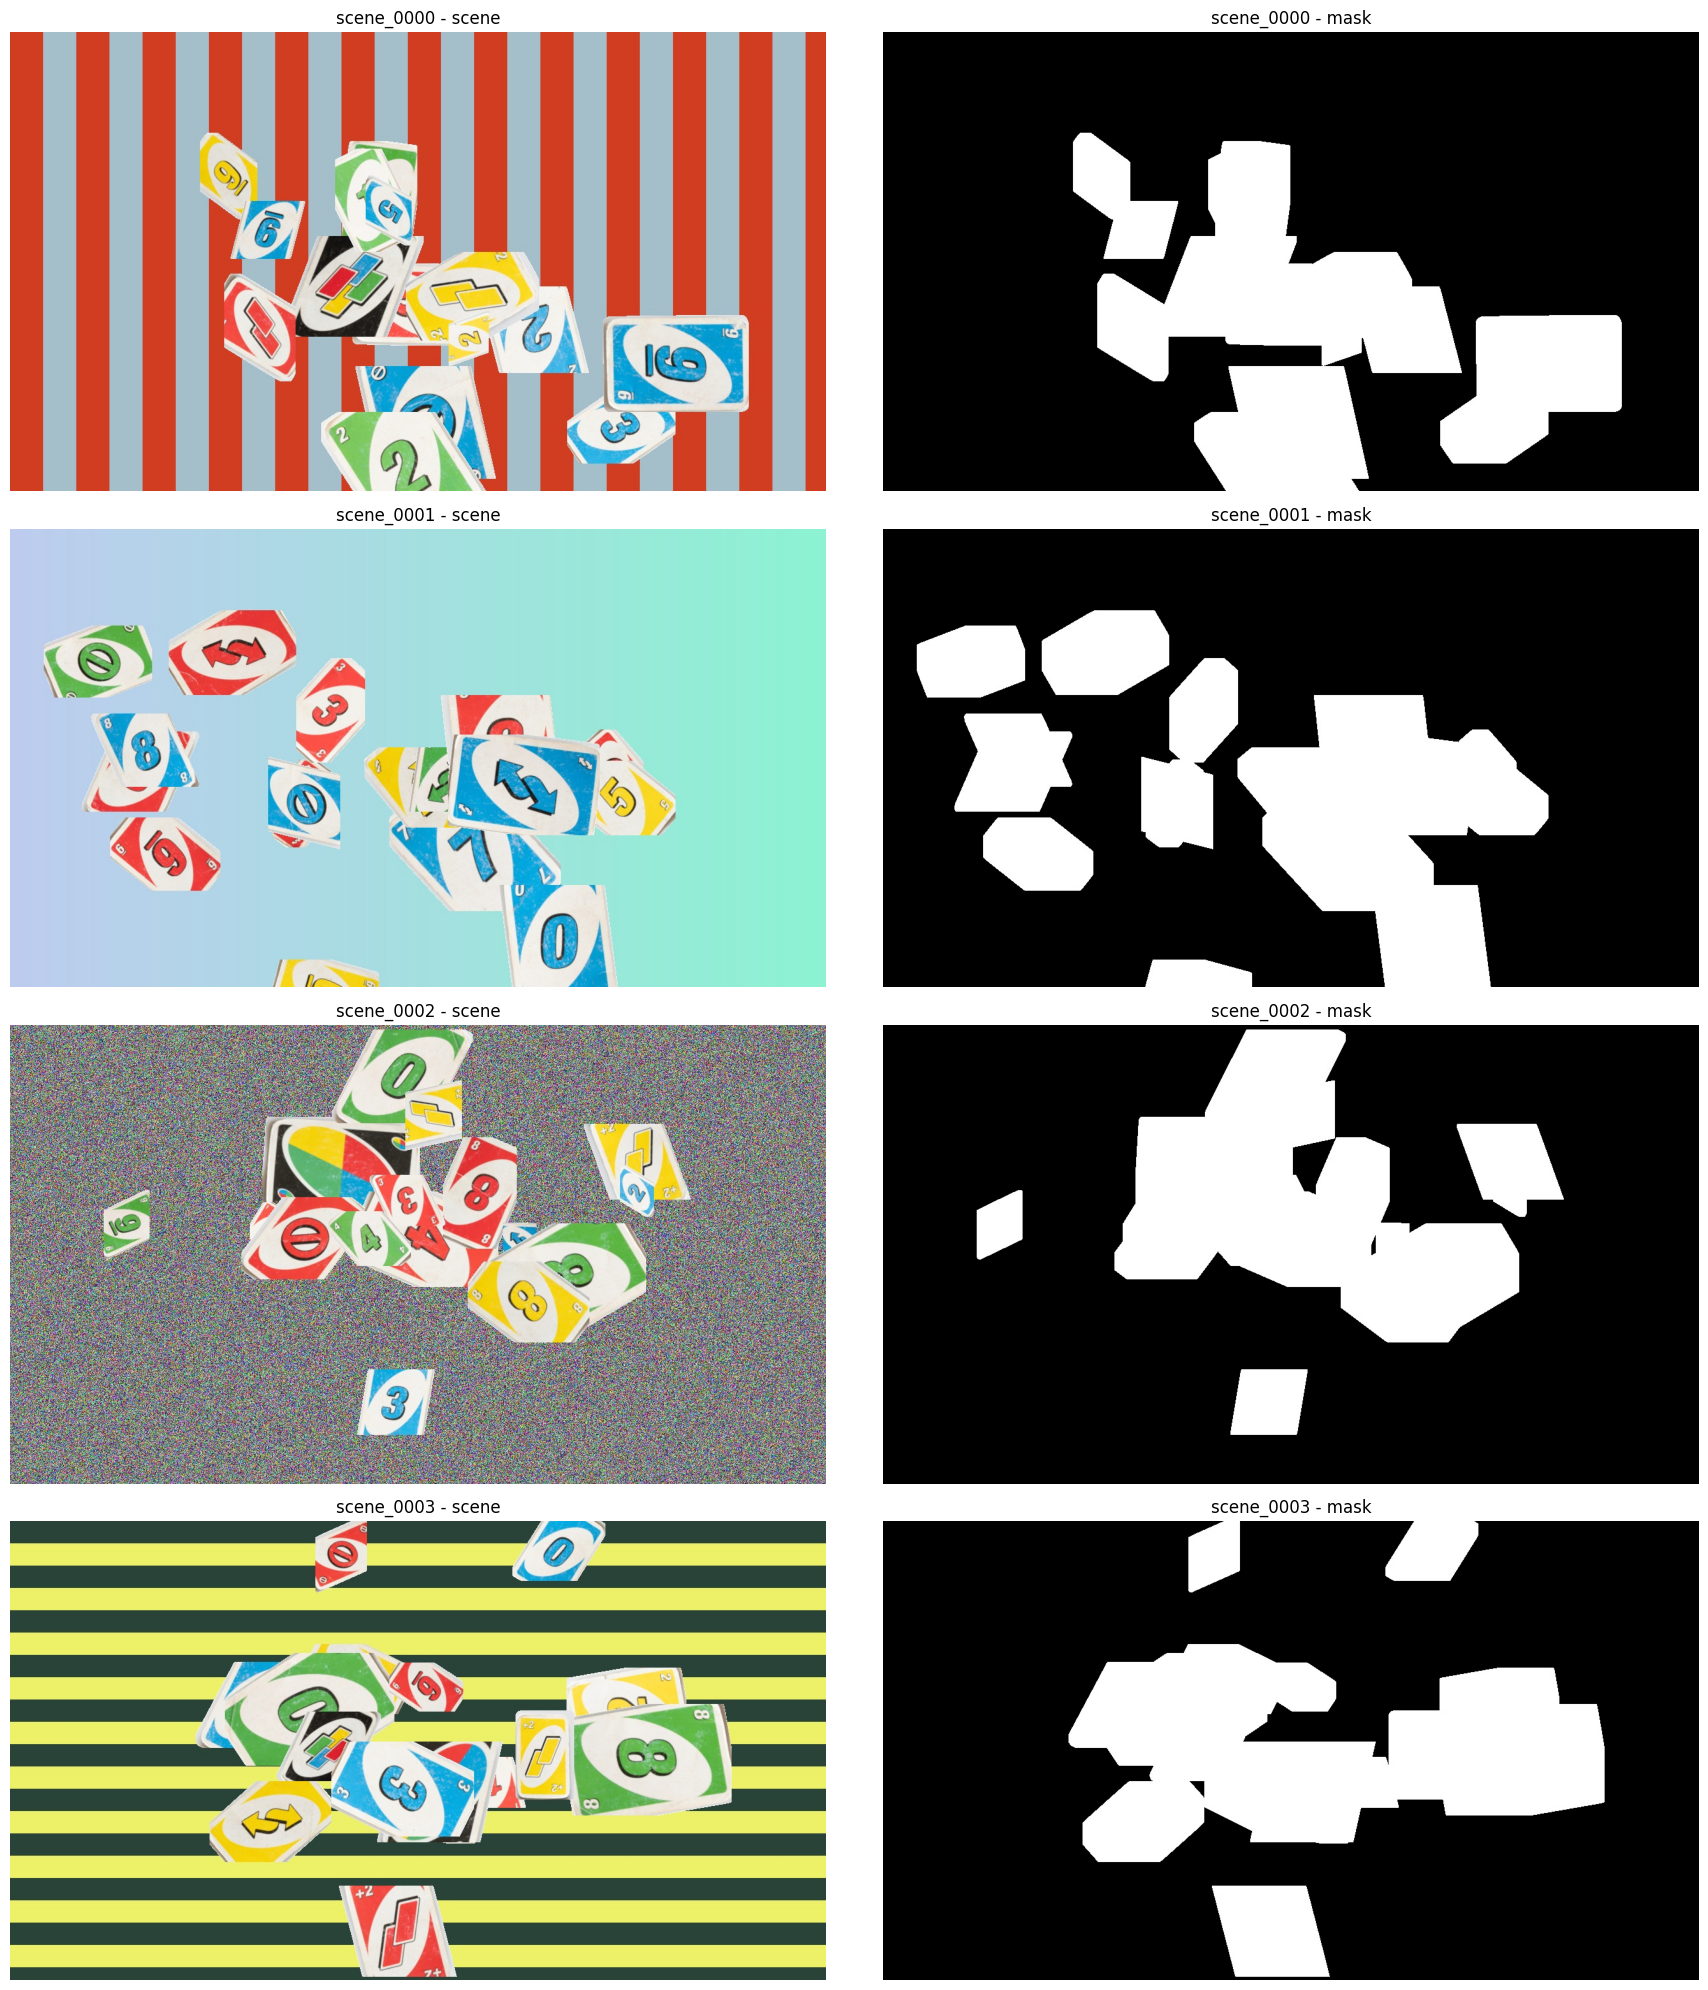

In [12]:
# Quick visual summary of saved snapshots and masks.
images_dir = GAME_SNAPSHOTS_DIR / "images"
masks_dir = GAME_SNAPSHOTS_DIR / "masks"

scene_files = sorted(images_dir.glob("scene_*.jpg"))[:4]
if not scene_files:
    raise FileNotFoundError(
        f"No scene files found in {images_dir}. Run the generation cell first."
    )

fig, axes = plt.subplots(len(scene_files), 2, figsize=(18, 5 * len(scene_files)))
if len(scene_files) == 1:
    axes = np.array([axes])

for row, scene_file in enumerate(scene_files):
    mask_file = masks_dir / scene_file.name
    scene_img = cv2.imread(str(scene_file), cv2.IMREAD_COLOR)
    mask_img = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
    if scene_img is None or mask_img is None:
        continue

    axes[row, 0].imshow(cv2.cvtColor(scene_img, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"{scene_file.stem} - scene")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask_img, cmap="gray")
    axes[row, 1].set_title(f"{scene_file.stem} - mask")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()